## Imports

In [116]:
import re
from collections import Counter
import sys
import os

sys.path.append(os.path.abspath("../numpy"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data import Data
from layers import DenseLayer
from activation import ReLUActivation, SoftmaxActivation
from neuralnet import NeuralNetwork
from losses import CategoricalCrossEntropy
from metrics import accuracy

## Ler os datasets

In [117]:
train_df = pd.read_csv("../dataset_distribuido_teste.csv", sep=";")
test_df = pd.read_csv("../subm2.csv", sep=";")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

Train shape: (2676, 3)
Test shape: (150, 2)


,ID,Text,Label
0,D1-0001,Signal transduction pathways are intricate com...,Google
1,D1-0002,The Diels-Alder reaction is a concerted [4+2] ...,Anthropic
2,D1-0003,The Hamiltonian of a N-boson system confined o...,Human
3,D1-0004,The study of exponential Diophantine equations...,OpenAI
4,D1-0005,The principle of least action states that the ...,Meta


,ID,Text
0,D2-101,Microbial mats of coexisting bacteria and arch...
1,D2-102,The origin of life on Earth remains a complex ...
2,D2-103,Estimates of the time at which life arose on E...
3,D2-104,Life on Earth emerged roughly 3.8-4 billion ye...
4,D2-105,Black holes predominantly form from the catast...


## Limpeza de texto

In [118]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def add_bigrams(text):
    words = text.split()
    bigrams = [words[i] + "_" + words[i+1] for i in range(len(words)-1)]
    return " ".join(words + bigrams)


cleanText=False ####################################### mudar 

if cleanText:
    train_df["clean_text"] = train_df["Text"].apply(clean_text)
    test_df["clean_text"] = test_df["Text"].apply(clean_text)
    print("com texto limpo")
else:
    train_df["clean_text"] = train_df["Text"]
    test_df["clean_text"] = test_df["Text"]
    print("sem texto limpo")

display(train_df[["Text", "clean_text", "Label"]].head())

sem texto limpo


,Text,clean_text,Label
0,Signal transduction pathways are intricate com...,Signal transduction pathways are intricate com...,Google
1,The Diels-Alder reaction is a concerted [4+2] ...,The Diels-Alder reaction is a concerted [4+2] ...,Anthropic
2,The Hamiltonian of a N-boson system confined o...,The Hamiltonian of a N-boson system confined o...,Human
3,The study of exponential Diophantine equations...,The study of exponential Diophantine equations...,OpenAI
4,The principle of least action states that the ...,The principle of least action states that the ...,Meta


## Ver classes

In [119]:
print("Classes:")
print(train_df["Label"].value_counts())

Classes:
Label
Human        892
Google       446
Anthropic    446
OpenAI       446
Meta         446
Name: count, dtype: int64


## Construir vocabulário

Bag of Words

In [120]:
def build_vocab(texts, max_features=20000, min_freq=2):
    counter = Counter()
    
    for text in texts:
        counter.update(text.split())
    
    vocab_items = [
        word for word, freq in counter.items()
        if freq >= min_freq
    ]
    
    vocab_items = sorted(
        vocab_items,
        key=lambda word: counter[word],
        reverse=True
    )[:max_features]
    
    vocab = {word: idx for idx, word in enumerate(vocab_items)}
    return vocab



## Transformar texto em Bag of Words

In [121]:
def text_to_bow(texts, vocab):
    X = np.zeros((len(texts), len(vocab)), dtype=np.float32)
    
    for i, text in enumerate(texts):
        for word in text.split():
            if word in vocab:
                X[i, vocab[word]] += 1.0
                
    return X


## Transformar texto em TFIDF

In [122]:
def compute_idf(texts, vocab):
    n_docs = len(texts)
    df = np.zeros(len(vocab), dtype=np.float32)

    for text in texts:
        seen_words = set()
        for word in text.split():
            if word in vocab and word not in seen_words:
                df[vocab[word]] += 1
                seen_words.add(word)

    idf = np.log((n_docs + 1) / (df + 1)) + 1
    return idf

def text_to_tfidf(texts, vocab, idf):
    X = np.zeros((len(texts), len(vocab)), dtype=np.float32)

    for i, text in enumerate(texts):
        words = text.split()
        if len(words) == 0:
            continue

        for word in words:
            if word in vocab:
                X[i, vocab[word]] += 1.0

        X[i] = X[i] / len(words)
        X[i] = X[i] * idf

        norm = np.linalg.norm(X[i])
        if norm > 0:
            X[i] = X[i] / norm


    return X


## Codificar labels

In [123]:
def fit_label_encoder(labels):
    classes = sorted(labels.unique())
    label_to_idx = {label: i for i, label in enumerate(classes)}
    idx_to_label = {i: label for label, i in label_to_idx.items()}
    return label_to_idx, idx_to_label

def encode_labels(labels, label_to_idx):
    return np.array([label_to_idx[label] for label in labels], dtype=np.int32)

def one_hot_encode(y, num_classes):
    y_onehot = np.zeros((len(y), num_classes), dtype=np.float32)
    y_onehot[np.arange(len(y)), y] = 1.0
    return y_onehot


## Split treino / validação

In [ ]:
def train_val_split(X, y, val_size=0.1, seed=42):
    np.random.seed(seed)
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    
    split_idx = int(len(X) * (1 - val_size))
    train_idx = indices[:split_idx]
    val_idx = indices[split_idx:]
    
    return X[train_idx], X[val_idx], y[train_idx], y[val_idx]

def train_val_test_split(X, y, val_size = 0.1, test_size = 0.1, seed=42):
    np.random.seed(seed)
    indices = np.arange(len(X))
    np.random.shuffle(indices)

    split1_idx = int(len(X) * (1 - val_size - test_size))
    split2_idx = int(len(X) * (1 - test_size))
    train_idx = indices[:split1_idx]
    val_idx = indices[split1_idx:split2_idx]
    test_idx = indices[split2_idx:]

    return X[train_idx], X[val_idx], X[test_idx] ,y[train_idx], y[val_idx], y[test_idx]

texts = train_df["clean_text"].to_numpy()
labels = train_df["Label"].to_numpy()

X_train_text, X_val_text, X_test_text, y_train_text, y_val_text, y_test_text = train_val_test_split(
    texts, labels, val_size=0.1, test_size = 0.1,seed=42
    )

print("X_train:", X_train_text.shape)
print("X_val:", X_val_text.shape)
print("y_train:", y_train_text.shape)
print("y_val:", y_val_text.shape)
print("X_test:", X_test_text.shape)
print("y_test:", y_test_text.shape)

X_train: (2140,)
X_val: (268,)
y_train: (2140,)
y_val: (268,)
X_test: (268,)
y_test: (268,)


In [125]:
def fit_vectorizer(texts_train, use_tfidf=True, use_bigrams=False, max_features=15000, min_freq=2):
    if use_bigrams:
        texts_train = np.array([add_bigrams(t) for t in texts_train])

    vocab = build_vocab(texts_train, max_features=max_features, min_freq=min_freq)

    vectorizer = {
        "use_tfidf": use_tfidf,
        "use_bigrams": use_bigrams,
        "vocab": vocab,
        "idf": None
    }

    if use_tfidf:
        vectorizer["idf"] = compute_idf(texts_train, vocab)

    return vectorizer

In [126]:
def transform_texts(texts, vectorizer):
    if vectorizer["use_bigrams"]:
        texts = np.array([add_bigrams(t) for t in texts])

    vocab = vectorizer["vocab"]

    if vectorizer["use_tfidf"]:
        idf = vectorizer["idf"]
        return text_to_tfidf(texts, vocab, idf)
    else:
        return text_to_bow(texts, vocab)

In [127]:
def run_experiment(
    model_name,
    texts_train,
    texts_val,
    y_train,
    y_val,
    use_tfidf=True,
    use_bigrams=False,
    max_features=15000,
    min_freq=2,
    epochs=50,
    batch_size=32,
    learning_rate=None,
    momentum=0.9
):
    vectorizer = fit_vectorizer(
        texts_train,
        use_tfidf=use_tfidf,
        use_bigrams=use_bigrams,
        max_features=max_features,
        min_freq=min_freq
    )

    X_train = transform_texts(texts_train, vectorizer)
    X_val = transform_texts(texts_val, vectorizer)

    train_data = Data(X_train, y_train)
    val_data = Data(X_val, y_val)

    if model_name == "logreg":
        if learning_rate is None:
            learning_rate = 0.05

        model = NeuralNetwork(
            epochs=epochs,
            batch_size=batch_size,
            learning_rate=learning_rate,
            momentum=momentum,
            verbose=False,
            loss=CategoricalCrossEntropy,
            metric=accuracy
        )
        model.add(DenseLayer(y_train.shape[1], input_shape=(X_train.shape[1],), l2_lambda=1e-4))
        model.add(SoftmaxActivation())

    elif model_name == "dnn":
        if learning_rate is None:
            learning_rate = 0.1

        model = NeuralNetwork(
            epochs=epochs,
            batch_size=batch_size,
            learning_rate=learning_rate,
            momentum=momentum,
            verbose=False,
            loss=CategoricalCrossEntropy,
            metric=accuracy
        )
        model.add(DenseLayer(128, input_shape=(X_train.shape[1],), l2_lambda=1e-4))
        model.add(ReLUActivation())
        model.add(DenseLayer(64, l2_lambda=1e-4))
        model.add(ReLUActivation())
        model.add(DenseLayer(y_train.shape[1], l2_lambda=1e-4))
        model.add(SoftmaxActivation())

    else:
        raise ValueError("model_name must be 'logreg' or 'dnn'")

    model.fit(train_data, val_dataset=val_data, early_stopping=True, patience=5)

    preds = model.predict(val_data)
    acc = accuracy(y_val, preds)

    return {
        "model": model,
        "vectorizer": vectorizer,
        "val_accuracy": acc,
        "history": model.history
    }

In [128]:
texts = train_df["clean_text"].to_numpy()
labels = train_df["Label"].to_numpy()

X_train_text, X_val_text, X_test_text, y_train_text, y_val_text, y_test_text = train_val_test_split(
    texts, labels, val_size=0.1, test_size=0.1, seed=42
)

label_to_idx, idx_to_label = fit_label_encoder(train_df["Label"])

y_train_idx = encode_labels(y_train_text, label_to_idx)
y_val_idx = encode_labels(y_val_text, label_to_idx)

num_classes = len(label_to_idx)
y_train = one_hot_encode(y_train_idx, num_classes)
y_val = one_hot_encode(y_val_idx, num_classes)

## Modelos


In [129]:
results = {}

results["logreg_bow"] = run_experiment(
    model_name="logreg",
    texts_train=X_train_text,
    texts_val=X_val_text,
    y_train=y_train,
    y_val=y_val,
    use_tfidf=False,
    use_bigrams=False
)

results["logreg_tfidf"] = run_experiment(
    model_name="logreg",
    texts_train=X_train_text,
    texts_val=X_val_text,
    y_train=y_train,
    y_val=y_val,
    use_tfidf=True,
    use_bigrams=False
)

results["logreg_tfidf_bigram"] = run_experiment(
    model_name="logreg",
    texts_train=X_train_text,
    texts_val=X_val_text,
    y_train=y_train,
    y_val=y_val,
    use_tfidf=True,
    use_bigrams=True
)


results["dnn_bow"] = run_experiment(
    model_name="dnn",
    texts_train=X_train_text,
    texts_val=X_val_text,
    y_train=y_train,
    y_val=y_val,
    use_tfidf=False,
    use_bigrams=False
)

results["dnn_tfidf"] = run_experiment(
    model_name="dnn",
    texts_train=X_train_text,
    texts_val=X_val_text,
    y_train=y_train,
    y_val=y_val,
    use_tfidf=True,
    use_bigrams=False
)



results["dnn_tfidf_bigram"] = run_experiment(
    model_name="dnn",
    texts_train=X_train_text,
    texts_val=X_val_text,
    y_train=y_train,
    y_val=y_val,
    use_tfidf=True,
    use_bigrams=True
)

Early stopping at epoch 13
Early stopping at epoch 18
Early stopping at epoch 17


## Graficos

In [130]:
def plot_history(history, title="Model"):
    epochs = list(history.keys())

    train_loss = [history[e]["loss"] for e in epochs]
    val_loss = [history[e]["val_loss"] for e in epochs]
    train_acc = [history[e]["metric"] for e in epochs]
    val_acc = [history[e]["val_metric"] for e in epochs]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

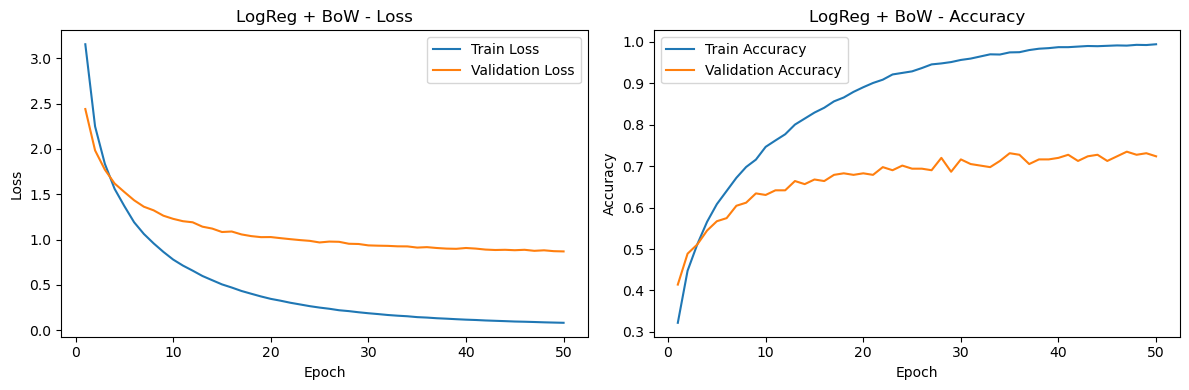

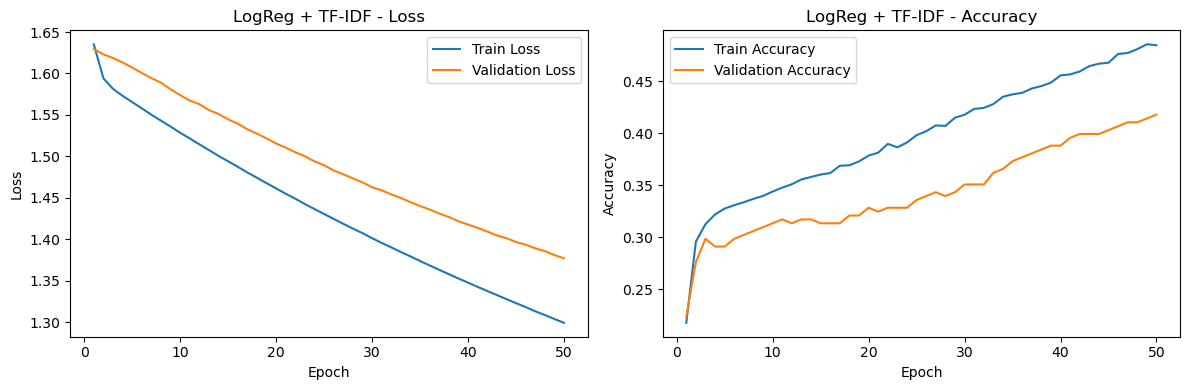

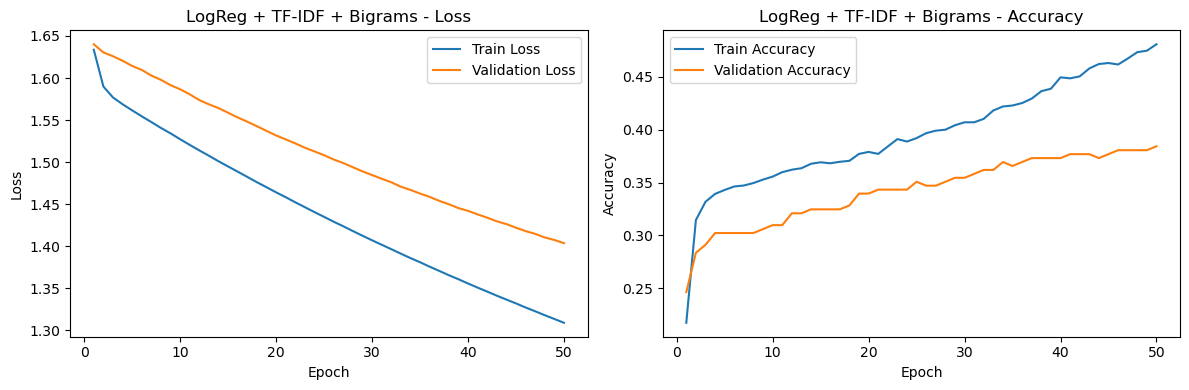

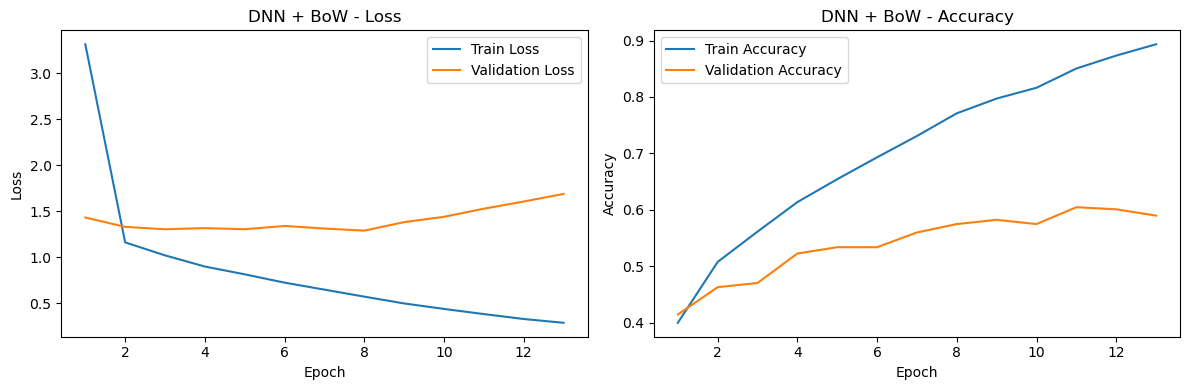

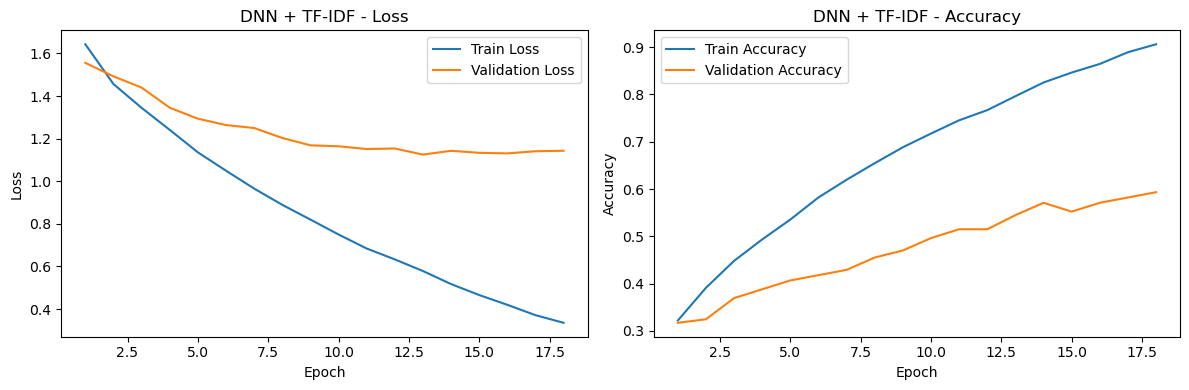

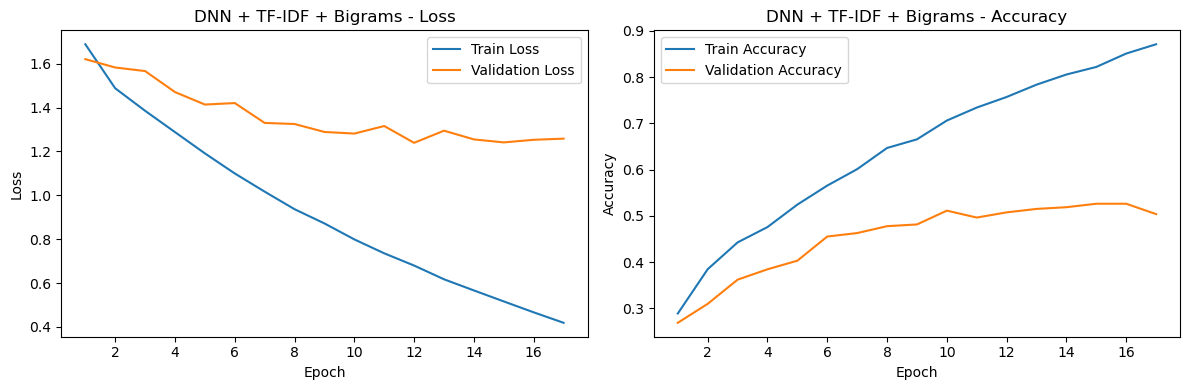

In [131]:
plot_history(results["logreg_bow"]["history"], title="LogReg + BoW")
plot_history(results["logreg_tfidf"]["history"], title="LogReg + TF-IDF")
plot_history(results["logreg_tfidf_bigram"]["history"], title="LogReg + TF-IDF + Bigrams")
plot_history(results["dnn_bow"]["history"], title="DNN + BoW")
plot_history(results["dnn_tfidf"]["history"], title="DNN + TF-IDF")
plot_history(results["dnn_tfidf_bigram"]["history"], title="DNN + TF-IDF + Bigrams")

## Escolher o melhor modelo

In [132]:
for name, result in results.items():
    print(name, "->", result["val_accuracy"])

best_model_name = max(results, key=lambda k: results[k]["val_accuracy"])
best_result = results[best_model_name]

best_model = best_result["model"]
best_vectorizer = best_result["vectorizer"]

print("Best model:", best_model_name)
print("Validation accuracy:", best_result["val_accuracy"])

logreg_bow -> 0.7238805970149254
logreg_tfidf -> 0.417910447761194
logreg_tfidf_bigram -> 0.3843283582089552
dnn_bow -> 0.5746268656716418
dnn_tfidf -> 0.5447761194029851
dnn_tfidf_bigram -> 0.5074626865671642
Best model: logreg_bow
Validation accuracy: 0.7238805970149254


# TESTE COM SUMB1 COM LABELS

In [133]:
test_df = pd.read_csv("../subm1_labels_revealed.csv", sep=";")

# print(X_test_text)
# print(y_test_text)
display(test_df.head())

,ID,Text,Label
0,D2-1,A covalent bond is a chemical bond that involv...,Human
1,D2-2,A covalent bond forms when two atoms share one...,Anthropic
2,D2-3,A covalent bond is a type of chemical bond whe...,OpenAI
3,D2-4,A covalent bond is a chemical bond that involv...,Meta
4,D2-5,Driven by exciting developments in the field o...,Human


In [134]:
test_df["clean_text"] = test_df["Text"]
#val_test_df["clean_text"] = val_test_df["Text"].apply(clean_text)
texts_test = test_df["clean_text"].to_numpy()
labels_test = test_df["Label"].to_numpy()

texts_test = np.concatenate((texts_test, X_test_text))
labels_test = np.concatenate((labels_test, y_test_text))

# print(len(X_test_text))
# print(len(y_test_text))
# print(len(texts_test))
# print(len(labels_test))

In [135]:
test_results = {}

true_idx = np.array([label_to_idx[label] for label in labels_test])
print(len(true_idx))

for name, result in results.items():
    model = result["model"]
    vectorizer = result["vectorizer"]

    X_val_test = transform_texts(texts_test, vectorizer)

    val_test_data = Data(X_val_test, y=None)

    preds = model.predict(val_test_data)
    pred_idx = np.argmax(preds, axis=1)

    acc = np.mean(pred_idx == true_idx)

    test_results[name] = acc
    print(f"{name}: {acc:.4f}")

368
logreg_bow: 0.6033
logreg_tfidf: 0.4130
logreg_tfidf_bigram: 0.4130
dnn_bow: 0.5082
dnn_tfidf: 0.5027
dnn_tfidf_bigram: 0.5054


In [136]:
pred_labels = [idx_to_label[i] for i in pred_idx]
for i in range(10):
    print("Texto:", test_df["Text"].iloc[i][:80])
    print("Real:", test_df["Label"].iloc[i])
    print("Pred:", pred_labels[i])
    print("---")

Texto: A covalent bond is a chemical bond that involves the sharing of electrons to for
Real: Human
Pred: Human
---
Texto: A covalent bond forms when two atoms share one or more pairs of electrons, rathe
Real: Anthropic
Pred: Anthropic
---
Texto: A covalent bond is a type of chemical bond where two atoms share one or more pai
Real: OpenAI
Pred: Google
---
Texto: A covalent bond is a chemical bond that involves the sharing of electron pairs b
Real: Meta
Pred: Meta
---
Texto: Driven by exciting developments in the field of nanotechnology, which is one of 
Real: Human
Pred: Meta
---
Texto: Ionic bonding results from the electrostatic attraction of oppositely charged io
Real: Human
Pred: Human
---
Texto: Plate tectonics is the scientific theory explaining how Earth's lithosphere—the 
Real: Anthropic
Pred: Anthropic
---
Texto: Plate tectonics is a fundamental scientific theory explaining the large-scale mo
Real: Google
Pred: Meta
---
Texto: Tectonic plates are relatively rigid and float acr

# Predict Submision

In [137]:
model_name = "logreg_bow"   # escolhe aqui
#model_name = max(results, key=lambda k: results[k]["val_accuracy"])

In [138]:
selected_result = results[model_name]

model = selected_result["model"]
vectorizer = selected_result["vectorizer"]

print("Using model:", model_name)

Using model: logreg_bow


In [139]:
X_test = transform_texts(test_df["clean_text"].to_numpy(), vectorizer)

In [140]:
test_data = Data(X_test, y=None)

In [141]:
pred_probs = model.predict(test_data)
pred_idx = np.argmax(pred_probs, axis=1)

In [142]:
pred_labels = [idx_to_label[i] for i in pred_idx]

In [143]:
submission = pd.DataFrame({
    "ID": test_df["ID"],
    "Label": pred_labels
})

submission.to_csv("subm2-g6-MEI-AV2.csv", sep=";", index=False)
display(submission.head())

,ID,Label
0,D2-1,Human
1,D2-2,Meta
2,D2-3,Meta
3,D2-4,Google
4,D2-5,Human
